In [1]:
import numpy as np
import pandas as pd

votes = pd.read_csv("../data/processed/votes.csv")
res = pd.read_csv("../data/processed/resolutions.csv", parse_dates=["date"])

M = votes.pivot(index="ms_code", columns="undl_id", values="vote")
print(M.shape)   # countries x resolutions

(202, 5694)


In [2]:
MIN_COMMON = 20   # ignore pairs with too few shared votes

def agreement_matrix(M):
    A = M.to_numpy()
    valid = (~np.isnan(A)).astype(float)
    common = valid @ valid.T                     # votes both countries cast
    agree = np.zeros_like(common)
    for v in (1.0, 0.0, -1.0):
        onehot = (A == v).astype(float)
        agree += onehot @ onehot.T               # votes where both chose v
    with np.errstate(invalid="ignore", divide="ignore"):
        S = agree / common
    S[common < MIN_COMMON] = np.nan
    S = pd.DataFrame(S, index=M.index, columns=M.index)
    C = pd.DataFrame(common, index=M.index, columns=M.index)
    return S, C

In [3]:
def window(M, start, end):
    ids = res.loc[(res["date"] >= start) & (res["date"] <= end), "undl_id"]
    sub = M[M.columns.intersection(ids)]
    return sub.dropna(how="all")                 # drop non-members

sub = window(M, "2000-01-01", "2025-12-31")
S, C = agreement_matrix(sub)
print(sub.shape)
S.loc["USA"].dropna().sort_values(ascending=False).head(10)

(195, 2232)


ms_code
USA    1.000000
ISR    0.828491
FSM    0.681561
MHL    0.581530
PLW    0.579434
CAN    0.522052
GBR    0.507886
AUS    0.461712
FRA    0.456963
HUN    0.427088
Name: USA, dtype: float64

In [4]:
S.loc["USA"].dropna().sort_values(ascending=False).head(10)

ms_code
USA    1.000000
ISR    0.828491
FSM    0.681561
MHL    0.581530
PLW    0.579434
CAN    0.522052
GBR    0.507886
AUS    0.461712
FRA    0.456963
HUN    0.427088
Name: USA, dtype: float64

In [5]:
sub = window(M, "2000-01-01", "2024-12-31")
S, C = agreement_matrix(sub)
S.loc["USA"].dropna().sort_values(ascending=False).head(10)

ms_code
USA    1.000000
ISR    0.833082
FSM    0.724845
MHL    0.631272
PLW    0.622593
CAN    0.555665
GBR    0.535767
AUS    0.490138
FRA    0.481006
HUN    0.445378
Name: USA, dtype: float64

In [6]:
  top = S.loc["USA"].drop("USA").dropna().sort_values(ascending=False).head(10)
  pd.DataFrame({"agreement": top.round(3), "shared_votes": C.loc["USA", top.index].astype(int)})

,agreement,shared_votes
ms_code,,
ISR,0.833,1989
FSM,0.725,1610
MHL,0.631,1714
PLW,0.623,1558
CAN,0.556,2030
GBR,0.536,2027
AUS,0.490,2028
FRA,0.481,2027
HUN,0.445,2023


In [7]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

names = pd.read_csv("../data/processed/countries.csv").set_index("ms_code")["name"]

def cluster_window(start, end, min_coverage=0.7, n_clusters=5):
    sub = window(M, start, end)
    coverage = sub.notna().mean(axis=1)          # share of resolutions each country voted on
    sub = sub[coverage >= min_coverage]
    S, C = agreement_matrix(sub)
    D = 1 - S                                    # distance = 1 - agreement
    D = D.fillna(D.stack().mean())               # fill rare gaps with the average distance
    Dm = D.to_numpy(copy=True)
    Dm = (Dm + Dm.T) / 2
    np.fill_diagonal(Dm, 0)
    Z = linkage(squareform(Dm, checks=False), method="average")
    labels = fcluster(Z, n_clusters, criterion="maxclust")
    return pd.Series(labels, index=D.index, name="cluster"), Z, S

In [8]:
clusters, Z, S = cluster_window("2000-01-01", "2024-12-31")

for c, members in clusters.groupby(clusters):
    codes = list(members.index)
    print(f"Cluster {c} ({len(codes)} countries):", ", ".join(codes[:40]),
          "..." if len(codes) > 40 else "")
    print()

Cluster 1 (2 countries): ISR, USA 

Cluster 2 (3 countries): FSM, MHL, PLW 

Cluster 3 (49 countries): ALB, AND, AUS, AUT, BEL, BGR, BIH, CAN, CHE, CYP, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GEO, GRC, HRV, HUN, IRL, ISL, ITA, JPN, KOR, LIE, LTU, LUX, LVA, MCO, MDA, MKD, MLT, MNE, NLD, NOR, NZL, POL ...

Cluster 4 (121 countries): AFG, AGO, ARE, ARG, ARM, ATG, AZE, BDI, BEN, BFA, BGD, BHR, BHS, BLR, BLZ, BOL, BRA, BRB, BRN, BTN, BWA, CHL, CHN, CIV, CMR, COG, COL, COM, CPV, CRI, CUB, DJI, DOM, DZA, ECU, EGY, ERI, ETH, FJI, GAB ...

Cluster 5 (1 countries): RUS 



In [9]:
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

def embed_and_cluster(start, end, min_coverage=0.7, n_clusters=6):
    sub = window(M, start, end)
    sub = sub[sub.notna().mean(axis=1) >= min_coverage]
    S, C = agreement_matrix(sub)
    D = 1 - S
    D = D.fillna(D.stack().mean())
    Dm = D.to_numpy(copy=True)
    Dm = (Dm + Dm.T) / 2
    np.fill_diagonal(Dm, 0)
    coords = MDS(n_components=5, dissimilarity="precomputed",
                 random_state=42, normalized_stress="auto").fit_transform(Dm)
    labels = AgglomerativeClustering(n_clusters=n_clusters,
                                     linkage="ward").fit_predict(coords)
    out = pd.DataFrame(coords[:, :2], index=D.index, columns=["x", "y"])
    out["cluster"] = labels
    return out

emb = embed_and_cluster("2000-01-01", "2024-12-31", n_clusters=6)
print(emb["cluster"].value_counts().sort_index())

cluster
0    50
1    28
2     3
3    86
4     7
5     2
Name: count, dtype: int64


c:\dev\un-voting-explorer\.venv\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\dev\un-voting-explorer\.venv\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


In [10]:
emb["name"] = names.reindex(emb.index)

for c, grp in emb.groupby("cluster"):
    print(f"Cluster {c} ({len(grp)} countries)")
    print(", ".join(grp.index[:45]), "..." if len(grp) > 45 else "")
    print()

emb.loc[["LKA", "IND", "CHN", "BRA", "RUS", "USA", "ZAF", "SAU", "IRN"], "cluster"]

Cluster 0 (50 countries)
ALB, AND, ARM, AUS, AUT, BEL, BGR, BIH, CAN, CHE, CYP, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GEO, GRC, HRV, HUN, IRL, ISL, ITA, JPN, KOR, LIE, LTU, LUX, LVA, MCO, MDA, MKD, MLT, MNE, NLD, NOR, NZL, POL, PRT, ROU, SMR, SRB ...

Cluster 1 (28 countries)
ARG, BHS, BRA, CHL, CIV, CMR, COL, CRI, DOM, FJI, GTM, HND, HTI, MDG, MEX, MWI, PAN, PER, PNG, PRY, SLB, SLV, TGO, TLS, TON, URY, VUT, WSM 

Cluster 2 (3 countries)
FSM, MHL, PLW 

Cluster 3 (86 countries)
AFG, AGO, ARE, ATG, AZE, BDI, BEN, BFA, BGD, BHR, BLR, BLZ, BOL, BRB, BRN, BTN, BWA, COG, COM, CPV, CUB, DJI, DZA, ECU, EGY, ERI, ETH, GAB, GHA, GIN, GMB, GNB, GRD, GUY, IDN, IRQ, JAM, JOR, KAZ, KEN, KGZ, KHM, KWT, LAO, LBN ...

Cluster 4 (7 countries)
CHN, IND, IRN, PAK, PRK, RUS, SYR 

Cluster 5 (2 countries)
ISR, USA 



ms_code
LKA    3
IND    4
CHN    4
BRA    1
RUS    4
USA    5
ZAF    3
SAU    3
IRN    4
Name: cluster, dtype: int64

In [11]:
sub = window(M, "2000-01-01", "2024-12-31")
a = sub.loc[emb.index[emb["cluster"] == 4]].mean()
b = sub.loc[emb.index[emb["cluster"] == 3]].mean()
gap = (a - b).dropna().abs().sort_values(ascending=False).head(15)

info = res.set_index("undl_id").loc[gap.index, ["date", "resolution", "title"]]
info["mean_gap"] = gap.round(2)
info

,date,resolution,title,mean_gap
undl_id,,,,
3893808,2020-12-07,A/RES/75/40,Treaty on the Prohibition of Nuclear Weapons :...,1.62
3952170,2021-12-24,A/RES/76/231,"Reducing space threats through norms, rules an...",1.61
3996905,2022-12-07,A/RES/77/54,Treaty on the Prohibition of Nuclear Weapons :...,1.61
4068505,2024-12-02,A/RES/79/38,Treaty on the Prohibition of Nuclear Weapons :...,1.61
4067960,2024-12-02,A/RES/79/22,"Reducing space threats through norms, rules an...",1.60
3950567,2021-12-06,A/RES/76/34,Treaty on the Prohibition of Nuclear Weapons :...,1.60
4029004,2023-12-04,A/RES/78/35,Treaty on the Prohibition of Nuclear Weapons :...,1.60
4029225,2023-12-04,A/RES/78/20,"Reducing space threats through norms, rules an...",1.59
3996915,2022-12-07,A/RES/77/41,Destructive direct-ascent anti-satellite missi...,1.51


In [12]:
sub = window(M, "2000-01-01", "2024-12-31")

group4 = emb.index[emb["cluster"] == 4]
group3 = emb.index[emb["cluster"] == 3]

a = sub.loc[group4].mean()      # average vote of cluster 4 on each resolution
b = sub.loc[group3].mean()      # average vote of cluster 3 on each resolution
gap = (a - b).dropna().abs().sort_values(ascending=False).head(15)

info = res.set_index("undl_id").loc[gap.index, ["date", "resolution", "title"]]
info["mean_gap"] = gap.round(2)
pd.set_option("display.max_colwidth", 80)
info

,date,resolution,title,mean_gap
undl_id,,,,
3893808,2020-12-07,A/RES/75/40,Treaty on the Prohibition of Nuclear Weapons : resolution / adopted by the G...,1.62
3952170,2021-12-24,A/RES/76/231,"Reducing space threats through norms, rules and principles of responsible be...",1.61
3996905,2022-12-07,A/RES/77/54,Treaty on the Prohibition of Nuclear Weapons : resolution / adopted by the G...,1.61
4068505,2024-12-02,A/RES/79/38,Treaty on the Prohibition of Nuclear Weapons : resolution / adopted by the G...,1.61
4067960,2024-12-02,A/RES/79/22,"Reducing space threats through norms, rules and principles of responsible be...",1.60
3950567,2021-12-06,A/RES/76/34,Treaty on the Prohibition of Nuclear Weapons : resolution / adopted by the G...,1.60
4029004,2023-12-04,A/RES/78/35,Treaty on the Prohibition of Nuclear Weapons : resolution / adopted by the G...,1.60
4029225,2023-12-04,A/RES/78/20,"Reducing space threats through norms, rules and principles of responsible be...",1.59
3996915,2022-12-07,A/RES/77/41,Destructive direct-ascent anti-satellite missile testing : resolution / adop...,1.51


In [13]:
def agreement_matrix_soft(M, min_common=20):
    A = M.to_numpy()
    valid = (~np.isnan(A)).astype(float)
    common = valid @ valid.T
    onehot = {v: (A == v).astype(float) for v in (1.0, 0.0, -1.0)}
    dist = np.zeros_like(common)
    for u in onehot:
        for v in onehot:
            dist += abs(u - v) * (onehot[u] @ onehot[v].T)
    with np.errstate(invalid="ignore", divide="ignore"):
        S = 1 - dist / (2 * common)
    S[common < min_common] = np.nan
    S = pd.DataFrame(S, index=M.index, columns=M.index)
    C = pd.DataFrame(common, index=M.index, columns=M.index)
    return S, C

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def embed_and_cluster(start, end, min_coverage=0.7, n_clusters=6, soft=False):
    sub = window(M, start, end)
    sub = sub[sub.notna().mean(axis=1) >= min_coverage]
    S, C = agreement_matrix_soft(sub) if soft else agreement_matrix(sub)
    D = 1 - S
    D = D.fillna(D.stack().mean())
    Dm = D.to_numpy(copy=True)
    Dm = (Dm + Dm.T) / 2
    np.fill_diagonal(Dm, 0)
    coords = MDS(n_components=5, dissimilarity="precomputed",
                 random_state=42, normalized_stress="auto").fit_transform(Dm)
    labels = AgglomerativeClustering(n_clusters=n_clusters,
                                     linkage="ward").fit_predict(coords)
    out = pd.DataFrame(coords[:, :2], index=D.index, columns=["x", "y"])
    out["cluster"] = labels
    return out

In [15]:
emb_strict = embed_and_cluster("2000-01-01", "2024-12-31", n_clusters=6)
emb_soft = embed_and_cluster("2000-01-01", "2024-12-31", n_clusters=6, soft=True)

print("strict sizes:", emb_strict["cluster"].value_counts().sort_index().tolist())
print("soft sizes:  ", emb_soft["cluster"].value_counts().sort_index().tolist())

def together(e, a, b):
    return bool(e.loc[a, "cluster"] == e.loc[b, "cluster"])

pairs = [("IND", "CHN"), ("IND", "RUS"), ("PAK", "CHN"), ("IND", "PAK"),
         ("IND", "LKA"), ("CHN", "RUS"), ("USA", "ISR"), ("BRA", "ARG")]
for a_, b_ in pairs:
    print(f"{a_}-{b_}: strict={together(emb_strict, a_, b_)}  soft={together(emb_soft, a_, b_)}")

strict sizes: [50, 28, 3, 86, 7, 2]
soft sizes:   [93, 5, 45, 2, 27, 4]
IND-CHN: strict=True  soft=True
IND-RUS: strict=True  soft=False
PAK-CHN: strict=True  soft=True
IND-PAK: strict=True  soft=True
IND-LKA: strict=False  soft=True
CHN-RUS: strict=True  soft=False
USA-ISR: strict=True  soft=True
BRA-ARG: strict=True  soft=True


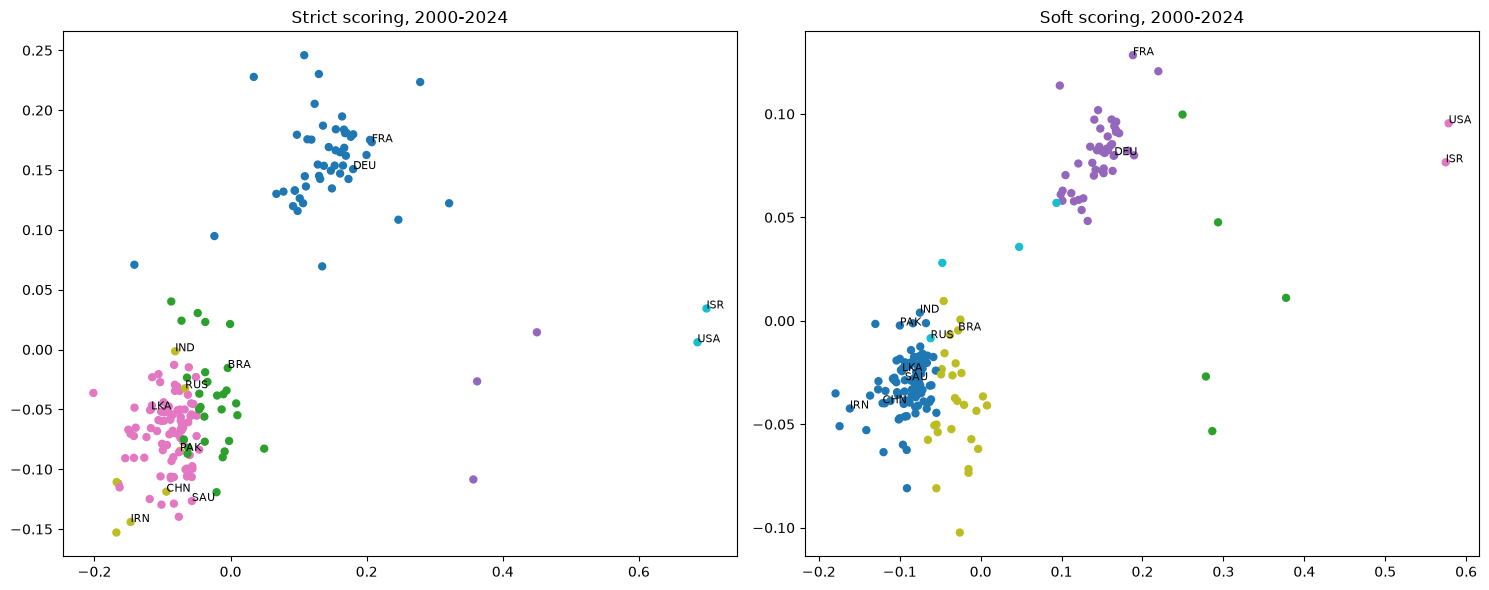

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, e, title in zip(axes, [emb_strict, emb_soft], ["Strict scoring", "Soft scoring"]):
    ax.scatter(e["x"], e["y"], c=e["cluster"], cmap="tab10", s=25)
    for code in ["USA", "RUS", "CHN", "IND", "PAK", "LKA", "BRA", "ISR", "FRA", "DEU", "SAU", "IRN"]:
        if code in e.index:
            ax.annotate(code, (e.loc[code, "x"], e.loc[code, "y"]), fontsize=8)
    ax.set_title(title + ", 2000-2024")
plt.tight_layout()
plt.savefig("../reports/voting_map_strict_vs_soft.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
  emb.to_csv("../data/processed/clusters_2000_2024.csv")

In [18]:
sub = window(M, "2000-01-01", "2024-12-31")
sub = sub[sub.notna().mean(axis=1) >= 0.7]
S_strict, C = agreement_matrix(sub)
S_soft, _ = agreement_matrix_soft(sub)

def rank_of(S, a, b):
    s = S.loc[a].drop(a).dropna().sort_values(ascending=False)
    order = list(s.index)
    return order.index(b) + 1 if b in order else None

rows = []
for a, b in [("IND", "CHN"), ("IND", "PAK"), ("IND", "RUS"), ("IND", "LKA"),
             ("CHN", "RUS"), ("PAK", "CHN"), ("IND", "USA"), ("IND", "FRA")]:
    rows.append({"pair": f"{a}-{b}",
                 "strict": round(S_strict.loc[a, b], 3),
                 "soft": round(S_soft.loc[a, b], 3),
                 "shared_votes": int(C.loc[a, b]),
                 "rank_of_2nd_in_1st's_list_strict": rank_of(S_strict, a, b),
                 "rank_soft": rank_of(S_soft, a, b)})
pd.DataFrame(rows)

,pair,strict,soft,shared_votes,rank_of_2nd_in_1st's_list_strict,rank_soft
0,IND-CHN,0.792,0.881,2008,39,20
1,IND-PAK,0.862,0.919,2010,1,1
2,IND-RUS,0.679,0.807,2021,116,115
3,IND-LKA,0.820,0.891,2016,4,4
4,CHN-RUS,0.756,0.855,2004,106,100
5,PAK-CHN,0.872,0.927,1994,2,5
6,IND-USA,0.157,0.276,2028,175,175
7,IND-FRA,0.432,0.610,2026,167,167


In [19]:
from sklearn.manifold import MDS
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

def distance_matrix(start, end, soft=False, min_coverage=0.7):
    sub = window(M, start, end)
    sub = sub[sub.notna().mean(axis=1) >= min_coverage]
    S, C = agreement_matrix_soft(sub) if soft else agreement_matrix(sub)
    D = 1 - S
    D = D.fillna(D.stack().mean())
    Dm = D.to_numpy(copy=True)
    Dm = (Dm + Dm.T) / 2
    np.fill_diagonal(Dm, 0)
    return pd.DataFrame(Dm, index=D.index, columns=D.columns)

D = distance_matrix("2000-01-01", "2024-12-31")
coords = MDS(n_components=5, dissimilarity="precomputed", random_state=42,
             normalized_stress="auto").fit_transform(D.to_numpy())

rows = []
for k in range(2, 11):
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
    sizes = np.bincount(labels)
    rows.append({"k": k,
                 "silhouette": round(silhouette_score(D.to_numpy(), labels, metric="precomputed"), 3),
                 "largest": sizes.max(), "smallest": sizes.min()})
pd.DataFrame(rows)

,k,silhouette,largest,smallest
0,2,0.671,121,55
1,3,0.685,121,5
2,4,0.416,93,5
3,5,0.415,86,5
4,6,0.415,86,2
5,7,0.387,86,2
6,8,0.368,86,2
7,9,0.364,86,2
8,10,0.249,46,2


In [20]:
for k in (2, 3):
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
    lab = pd.Series(labels, index=D.index)
    print(f"k={k}")
    for c, grp in lab.groupby(lab):
        codes = list(grp.index)
        print(f"  group {c} ({len(codes)}):", ", ".join(codes[:25]), "..." if len(codes) > 25 else "")
    print()

k=2
  group 0 (55): ALB, AND, ARM, AUS, AUT, BEL, BGR, BIH, CAN, CHE, CYP, CZE, DEU, DNK, ESP, EST, FIN, FRA, FSM, GBR, GEO, GRC, HRV, HUN, IRL ...
  group 1 (121): AFG, AGO, ARE, ARG, ATG, AZE, BDI, BEN, BFA, BGD, BHR, BHS, BLR, BLZ, BOL, BRA, BRB, BRN, BTN, BWA, CHL, CHN, CIV, CMR, COG ...

k=3
  group 0 (121): AFG, AGO, ARE, ARG, ATG, AZE, BDI, BEN, BFA, BGD, BHR, BHS, BLR, BLZ, BOL, BRA, BRB, BRN, BTN, BWA, CHL, CHN, CIV, CMR, COG ...
  group 1 (5): FSM, ISR, MHL, PLW, USA 
  group 2 (50): ALB, AND, ARM, AUS, AUT, BEL, BGR, BIH, CAN, CHE, CYP, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GEO, GRC, HRV, HUN, IRL, ISL ...



In [21]:
def silhouette_table(start, end, soft=False, ks=range(2, 9)):
    D = distance_matrix(start, end, soft=soft)
    coords = MDS(n_components=5, dissimilarity="precomputed", random_state=42,
                 normalized_stress="auto").fit_transform(D.to_numpy())
    out = []
    for k in ks:
        lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
        out.append(round(silhouette_score(D.to_numpy(), lab, metric="precomputed"), 3))
    return out, len(D)

for name, s, e, soft in [("2000-2024 strict", "2000-01-01", "2024-12-31", False),
                         ("2000-2024 soft",   "2000-01-01", "2024-12-31", True),
                         ("1980-1989 strict", "1980-01-01", "1989-12-31", False),
                         ("2010-2024 strict", "2010-01-01", "2024-12-31", False)]:
    scores, n = silhouette_table(s, e, soft)
    print(f"{name} ({n} countries): k=2..8 ->", scores)

2000-2024 strict (176 countries): k=2..8 -> [0.671, 0.685, 0.416, 0.415, 0.415, 0.387, 0.368]
2000-2024 soft (176 countries): k=2..8 -> [0.719, 0.725, 0.721, 0.43, 0.417, 0.403, 0.396]
1980-1989 strict (146 countries): k=2..8 -> [0.708, 0.654, 0.404, 0.405, 0.354, 0.356, 0.354]
2010-2024 strict (181 countries): k=2..8 -> [0.669, 0.67, 0.445, 0.444, 0.442, 0.431, 0.325]


In [22]:
D_soft = distance_matrix("2000-01-01", "2024-12-31", soft=True)
coords_soft = MDS(n_components=5, dissimilarity="precomputed", random_state=42,
                  normalized_stress="auto").fit_transform(D_soft.to_numpy())
lab4 = pd.Series(AgglomerativeClustering(n_clusters=4, linkage="ward")
                 .fit_predict(coords_soft), index=D_soft.index)
for c, grp in lab4.groupby(lab4):
    codes = list(grp.index)
    print(f"group {c} ({len(codes)}):", ", ".join(codes[:30]), "..." if len(codes) > 30 else "")

group 0 (120): AFG, AGO, ARE, ARG, ATG, AZE, BDI, BEN, BFA, BGD, BHR, BHS, BLR, BLZ, BOL, BRA, BRB, BRN, BTN, BWA, CHL, CHN, CIV, CMR, COG, COL, COM, CPV, CRI, CUB ...
group 1 (5): AUS, CAN, FSM, MHL, PLW 
group 2 (49): ALB, AND, ARM, AUT, BEL, BGR, BIH, CHE, CYP, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GEO, GRC, HRV, HUN, IRL, ISL, ITA, JPN, KOR, LIE, LTU, LUX, LVA ...
group 3 (2): ISR, USA 


In [23]:
def silhouette_without(start, end, drop, soft=False, ks=range(2, 9)):
    D = distance_matrix(start, end, soft=soft)
    keep = [c for c in D.index if c not in drop]
    D = D.loc[keep, keep]
    coords = MDS(n_components=5, dissimilarity="precomputed", random_state=42,
                 normalized_stress="auto").fit_transform(D.to_numpy())
    out = []
    for k in ks:
        lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(coords)
        out.append(round(silhouette_score(D.to_numpy(), lab, metric="precomputed"), 3))
    return out, len(D)

drop = ["USA", "ISR", "FSM", "MHL", "PLW"]
for name, soft in [("strict", False), ("soft", True)]:
    scores, n = silhouette_without("2000-01-01", "2024-12-31", drop, soft)
    print(f"2000-2024 {name}, outliers removed ({n} countries): k=2..8 ->", scores)

2000-2024 strict, outliers removed (171 countries): k=2..8 -> [0.7, 0.478, 0.437, 0.361, 0.33, 0.338, 0.236]
2000-2024 soft, outliers removed (171 countries): k=2..8 -> [0.757, 0.434, 0.422, 0.387, 0.308, 0.315, 0.302]


In [24]:
# Founding Western members, so the anchor exists for the whole period.
# The USA is left out on purpose so the 2025 pattern cannot distort it.
ANCHORS = ["GBR", "FRA", "CAN", "AUS", "NLD", "BEL", "NOR", "DNK"]

def anchor_agreement(start, end):
    sub = window(M, start, end)
    S, C = agreement_matrix(sub)
    cols = [a for a in ANCHORS if a in S.columns]
    s = S[cols].copy()
    for a in cols:
        s.loc[a, a] = np.nan          # ignore each anchor's agreement with itself
    return s.mean(axis=1)

periods = [(y, y + 4) for y in range(1950, 2025, 5)]    # ends at 2024; 2025 is excluded
label = lambda a, b: f"{a}-{str(b)[2:]}"

T = pd.DataFrame({label(a, b): anchor_agreement(f"{a}-01-01", f"{b}-12-31")
                  for a, b in periods})

# USSR and Russia as one series for plotting
T.loc["USSR/RUS"] = T.loc["SUN"].combine_first(T.loc["RUS"])
T.shape

(203, 15)

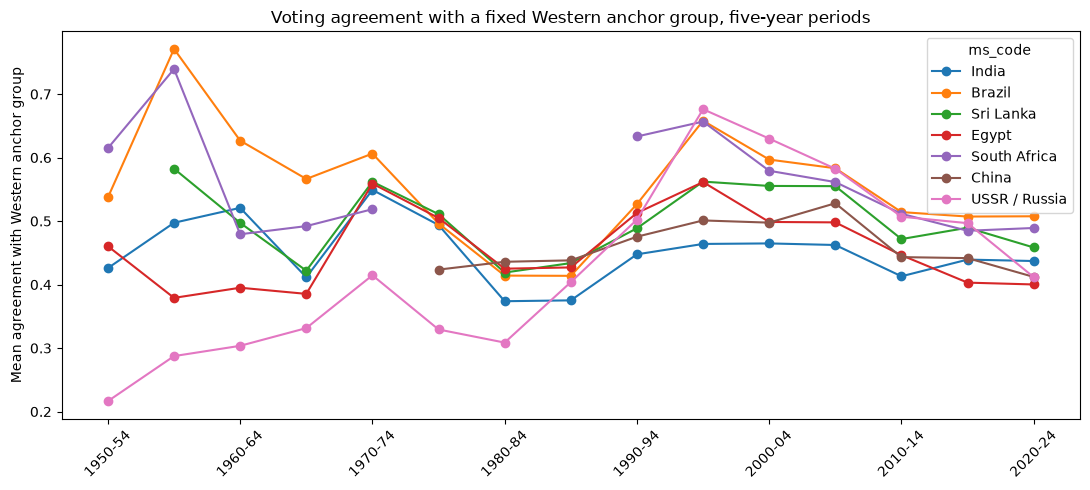

In [25]:
# The dataset uses one code for the Chinese seat throughout, but the seat
# changed governments in 1971, so periods starting before 1972 are hidden.
T_plot = T.copy()
for c in T_plot.columns:
    if int(c.split("-")[0]) < 1972:
        T_plot.loc["CHN", c] = np.nan

show = {"IND": "India", "BRA": "Brazil", "LKA": "Sri Lanka", "EGY": "Egypt",
        "ZAF": "South Africa", "CHN": "China", "USSR/RUS": "USSR / Russia"}

ax = T_plot.loc[list(show)].T.rename(columns=show).plot(figsize=(11, 5), marker="o")
ax.set_ylabel("Mean agreement with Western anchor group")
ax.set_title("Voting agreement with a fixed Western anchor group, five-year periods")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/agreement_with_west_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
rows = {}
for a, b in periods:
    w = window(M, f"{a}-01-01", f"{b}-12-31")
    rows[label(a, b)] = {"resolutions": w.shape[1], "countries": w.shape[0]}
pd.DataFrame(rows).T

,resolutions,countries
1950-54,74,60
1955-59,89,83
1960-64,96,113
1965-69,141,126
1970-74,330,138
1975-79,507,150
1980-84,712,158
1985-89,711,158
1990-94,368,186
1995-99,362,181


In [27]:
import pandas as pd

raw = pd.read_csv("../data/raw/2026_02_06_ga_voting.csv",
                  usecols=["ms_code", "ms_name", "date"], parse_dates=["date"])
g = (raw.groupby(["ms_code", "ms_name"])["date"]
        .agg(["min", "max", "size"]).reset_index())
g[g["ms_code"] == "CHN"]

,ms_code,ms_name,min,max,size
37,CHN,CHINA,1946-01-26,2025-12-18,5694


In [28]:
T_plot.loc[["USSR/RUS", "IND", "BRA", "EGY", "LKA"]].round(2).T

ms_code,USSR/RUS,IND,BRA,EGY,LKA
1950-54,0.22,0.43,0.54,0.46,NaN
1955-59,0.29,0.50,0.77,0.38,0.58
1960-64,0.30,0.52,0.63,0.40,0.50
1965-69,0.33,0.41,0.57,0.39,0.42
1970-74,0.41,0.55,0.61,0.56,0.56
1975-79,0.33,0.49,0.50,0.50,0.51
1980-84,0.31,0.37,0.41,0.43,0.42
1985-89,0.40,0.38,0.41,0.43,0.43
1990-94,0.50,0.45,0.53,0.51,0.49
1995-99,0.68,0.46,0.66,0.56,0.56
